# 비지도 학습
* 비지도 학습은 데이터에 대한 레이블 없이 입력 데이터의 패턴이나 구조를 학습하는 방법이다.
* 데이터에 대한 정답(레이블)이 없기 때문에 학습 과정에서 지도 학습처럼 입력-출력 관계를 학습하지 않고, 데이터를 스스로 그룹화하거나 내재된 특성을 찾아내는 데 초점이 맞춰진다.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import load_iris
from sklearn.decomposition import PCA

In [2]:
# 데이터 로드
iris = load_iris()
df = pd.DataFrame(data=iris.data, columns=iris.feature_names)
df

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


In [3]:
 # 결측치 확인

df.isnull().sum()

sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
dtype: int64

In [4]:

# 데이터 표준화 (Scaling)
# 군집화는 거리에 민감하므로 모든 특성의 스케일을 맞춰줍니다.

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

# K-Means Clustering

* K-Means는 “각 고객을 좌표(특징 벡터)로 보고”, 가까운 점끼리 묶는 군집화 알고리즘
* 주어진 데이터를 K개의 그룹으로 나누고, 각 데이터 포인트를 가장 가까운 클러스터 중심(centroid)에 할당하는 방식으로 동작 (K는 사용자가 선정)
* 알고리즘의 주요 단계
    * 초기화: K개의 클러스터 중심을 무작위로 선택한다.
    * 할당: 각 데이터 포인트를 가장 가까운 클러스터 중심에 할당한다.
    * 업데이트: 각 클러스터의 중심을 다시 계산한다. 클러스터에 포함된 데이터 포인트의 평균값으로 중심을 갱신한다.
    * 반복: 할당과 업데이트 단계를 중심 위치가 수렴하거나 특정 반복 횟수에 도달할 때까지 반복한다.

In [5]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# 엘보우 메소드 및 실루엣 스코어 확인
inertia = []
silhouette_scores = []
k_range = range(2, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    inertia.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, labels))

In [6]:
# k별 이너셔
for k in range(len(inertia)):
    print(f'k = {k_range[k]}, inertia = {inertia[k]:.4f}')

k = 2, inertia = 222.3617
k = 3, inertia = 139.8205
k = 4, inertia = 114.0925
k = 5, inertia = 90.9275
k = 6, inertia = 81.5444
k = 7, inertia = 72.6311
k = 8, inertia = 62.5406
k = 9, inertia = 55.1195
k = 10, inertia = 47.3910


Text(0.5, 1.0, 'Elbow Method')

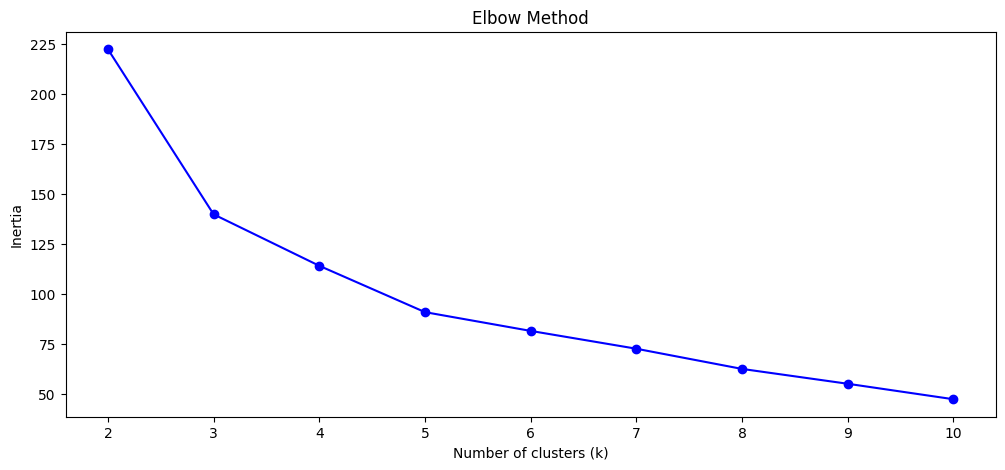

In [8]:
# Elbow Method 그래프 그리기

plt.figure(figsize=(12, 5))
plt.plot(k_range, inertia, marker='o', color='blue')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method')

In [9]:

# K별 실루엣 점수

for k in range(len(silhouette_scores)):
    print(f'k = {k_range[k]}, silhouette_scores = {silhouette_scores[k]:.4f}')

k = 2, silhouette_scores = 0.5818
k = 3, silhouette_scores = 0.4599
k = 4, silhouette_scores = 0.3869
k = 5, silhouette_scores = 0.3459
k = 6, silhouette_scores = 0.3171
k = 7, silhouette_scores = 0.3202
k = 8, silhouette_scores = 0.3387
k = 9, silhouette_scores = 0.3424
k = 10, silhouette_scores = 0.3518


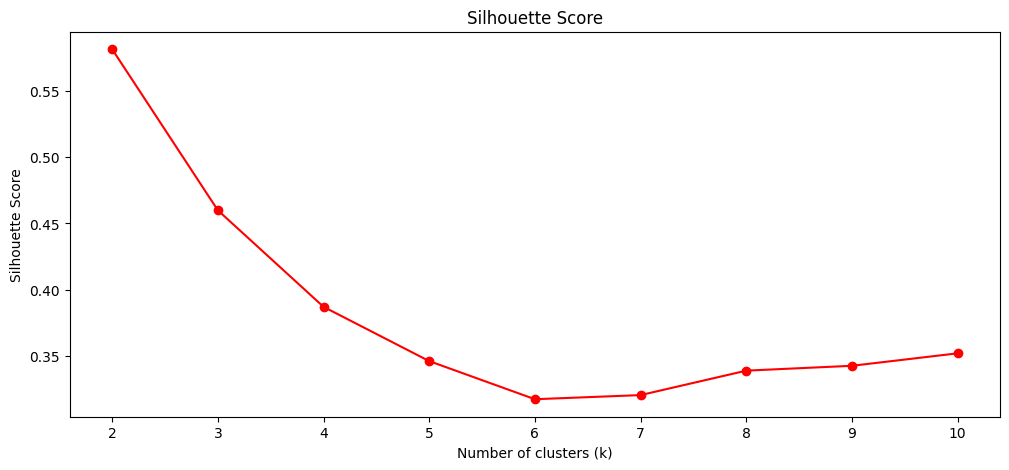

In [10]:

# 실루엣 점수 그래프 그리기

plt.figure(figsize=(12, 5))
plt.plot(k_range, silhouette_scores, marker='o', color='red')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score')
plt.show()

In [ ]:
# 최적의 k?

In [11]:
# K-Means 실행

kmeans = KMeans(n_clusters= 3, random_state=42, n_init=10)
df['kmeans_cluster'] = kmeans.fit_predict(X_scaled)
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),kmeans_cluster
0,5.1,3.5,1.4,0.2,1
1,4.9,3.0,1.4,0.2,1
2,4.7,3.2,1.3,0.2,1
3,4.6,3.1,1.5,0.2,1
4,5.0,3.6,1.4,0.2,1


In [13]:
# 시각화를 위한 PCA (4차원 -> 2차원 축소)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
df['pca_x'] = X_pca[:, 0]
df['pca_y'] = X_pca[:, 1]

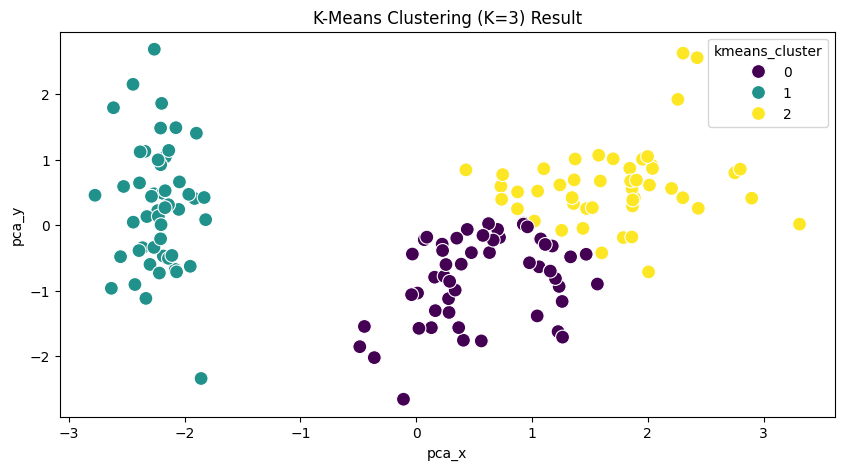

In [14]:
# 결과 시각화
plt.figure(figsize=(10, 5))
sns.scatterplot(x='pca_x', y='pca_y', hue='kmeans_cluster', data=df, palette='viridis', s=100)
plt.title('K-Means Clustering (K=3) Result')
plt.show()

#  정답과 얼마나 비슷한지 비교하기

* iris 데이터는 답을 가지고 있는 데이터이다.
* 실제 품종 열을 만들고 target의 이름을 매핑하여 군집 시각화하기.
* k-means 클러스터링 결과와 실제 데이터의 군집 간 비교하기.

In [15]:
#실제 품종 매핑
y = iris.target
df['true_species'] = iris.target_names[y]

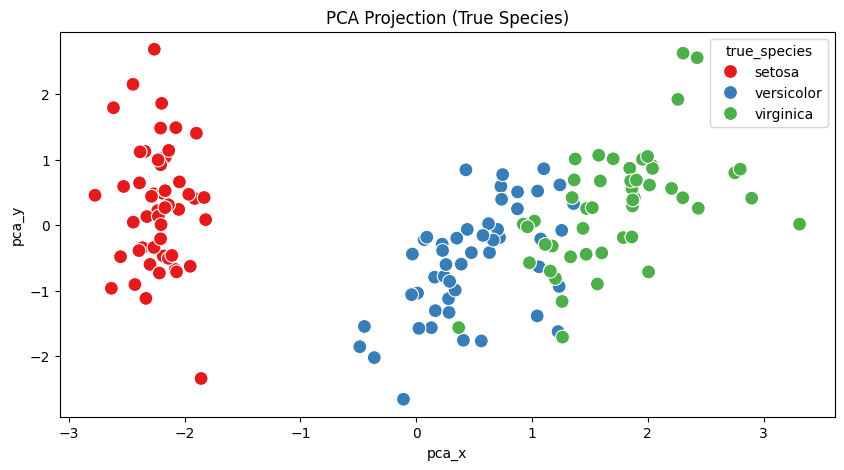

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
sns.scatterplot(
    x='pca_x',
    y='pca_y',
    hue='true_species',
    data=df,
    palette='Set1',
    s=100
)
plt.title('PCA Projection (True Species)')
plt.show()